In [12]:
import pandas as pd
import numpy as np
import shap
import json
import joblib
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
model = joblib.load("../artifacts/final_model.pkl")
with open("../artifacts/features.json") as f:
    feature_list = json.load(f)

df_train = pd.read_csv("../data/processed/train_encoded.csv")
df_test  = pd.read_csv("../data/processed/test_encoded.csv")

target = "price_in_USD"

X_train = df_train[feature_list]
X_test  = df_test[feature_list]

y_train = df_train[target]
y_test  = df_test[target]

In [3]:
X_sample = X_train.sample(10000, random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

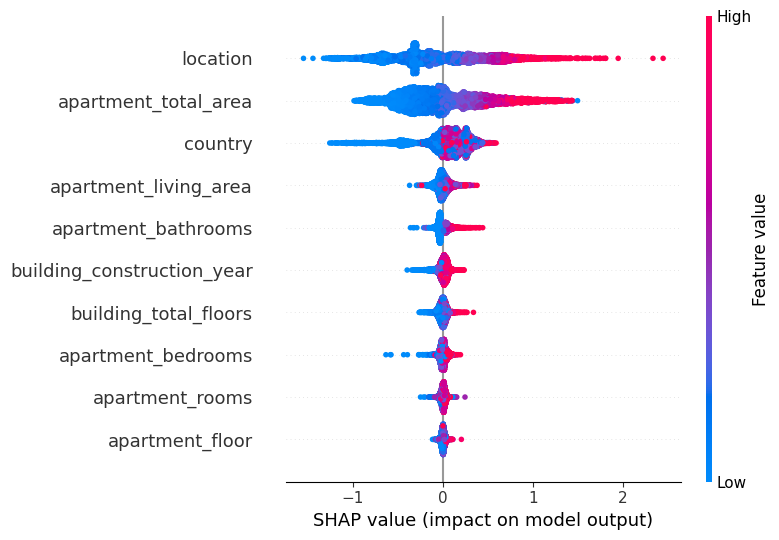

In [6]:
shap.summary_plot(shap_values, X_sample, plot_type="dot")

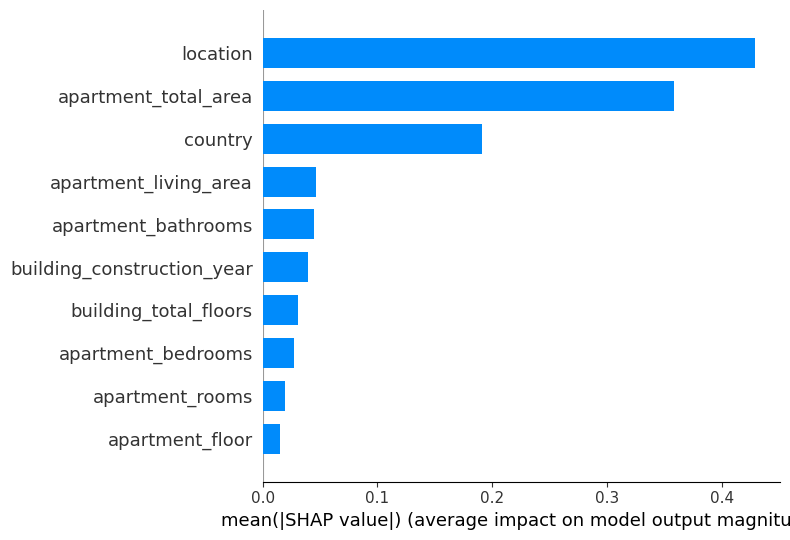

In [7]:
shap.summary_plot(shap_values, X_sample, plot_type="bar")

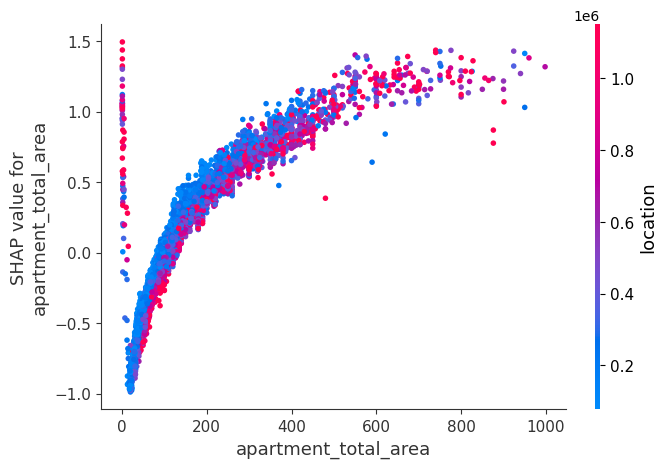

In [8]:
shap.dependence_plot("apartment_total_area", shap_values, X_sample)

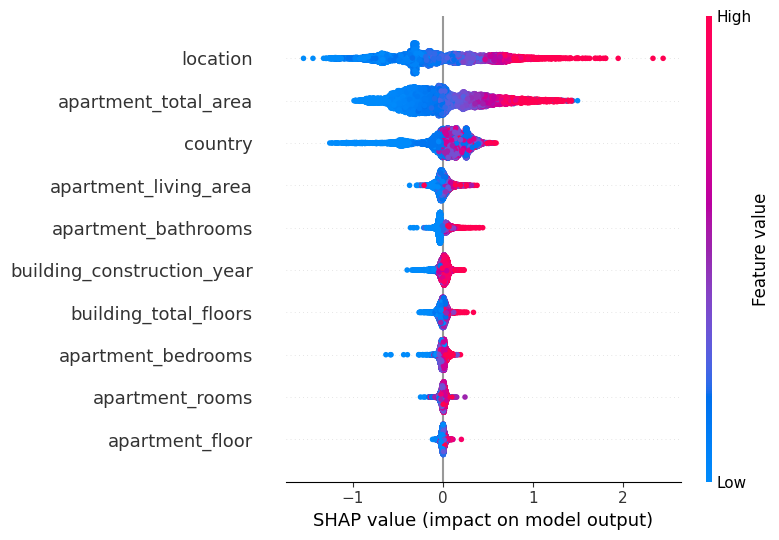

In [10]:
plt.figure()
shap.summary_plot(shap_values, X_sample, show=False)
plt.savefig("../artifacts/shap_summary_plot.png", dpi=300, bbox_inches="tight")

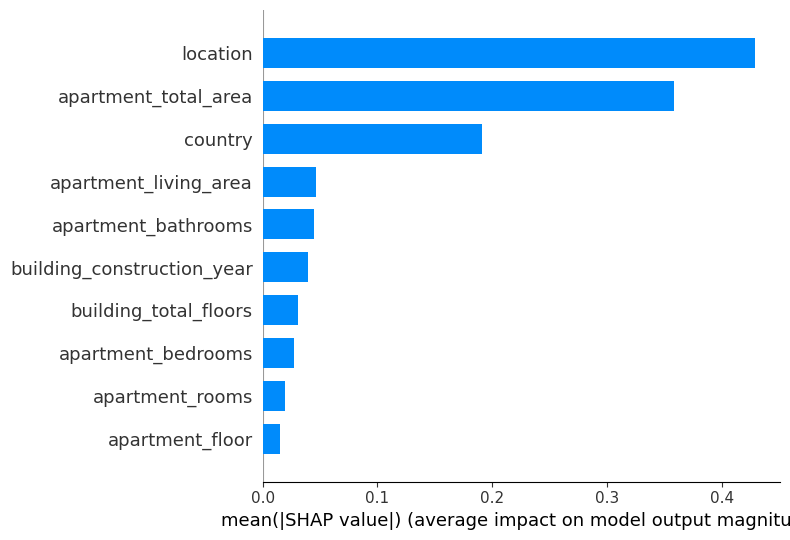

In [11]:
plt.figure()
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.savefig("../artifacts/shap_bar_plot.png", dpi=300, bbox_inches="tight")

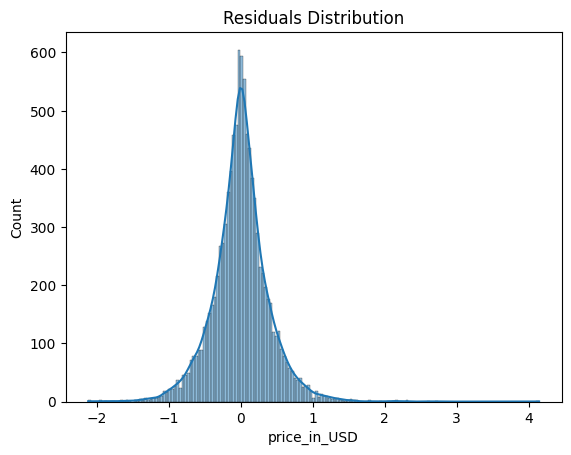

In [14]:
y_pred_log_sample = model.predict(X_sample)
residuals = y_pred_log_sample - y_train.sample(10000, random_state=42)

sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution")
plt.show()